# Etapa 1 — EDA + Modelos Baseline

**Problema de negócio:** Uma operadora de telecomunicações precisa identificar clientes com risco de cancelamento (churn) para agir proativamente.

**Dataset:** Telco Customer Churn — IBM (Kaggle) — 7.043 clientes, 33 variáveis.

**Objetivo:** Explorar os dados, entender distribuições e treinar modelos baseline rastreados no MLflow.

## 0. Setup

In [1]:


import logging
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score

from customer_churn_ibm.config import (
    CV_FOLDS,
    MLFLOW_EXPERIMENT,
    NUMERICAL_FEATURES,
    SEED,
    TARGET,
)
from customer_churn_ibm.data import build_preprocessor, clean_data, get_splits, load_raw_data
from customer_churn_ibm.model_baseline import BASELINE_CONFIGS, train_baselines

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(SEED)

print(f'SEED={SEED} | CV_FOLDS={CV_FOLDS}')

/Users/victor/Library/Caches/pypoetry/virtualenvs/customer-churn-ibm-wPk479TX-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SEED=42 | CV_FOLDS=5


## 1. Carregamento dos Dados

In [2]:
df_raw = load_raw_data()
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

INFO:customer_churn_ibm.data:Baixando dataset via kagglehub


INFO:customer_churn_ibm.data:Dataset carregado: 7043 linhas, 33 colunas


Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


## 2. Qualidade dos Dados

In [3]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'missing': missing, 'missing_%': missing_pct}).query('missing > 0')

,missing,missing_%
Churn Reason,5174,73.46


In [4]:
print(f'Duplicatas: {df_raw.duplicated().sum()}')
print(f'Total Charges (antes conversão): {df_raw["Total Charges"].dtype}')
# Total Charges é string — deve ser convertida
n_non_numeric = pd.to_numeric(df_raw['Total Charges'], errors='coerce').isna().sum()
print(f'Valores não-numéricos em Total Charges: {n_non_numeric}')

Duplicatas: 0
Total Charges (antes conversão): object
Valores não-numéricos em Total Charges: 11


## 3. Distribuição do Target

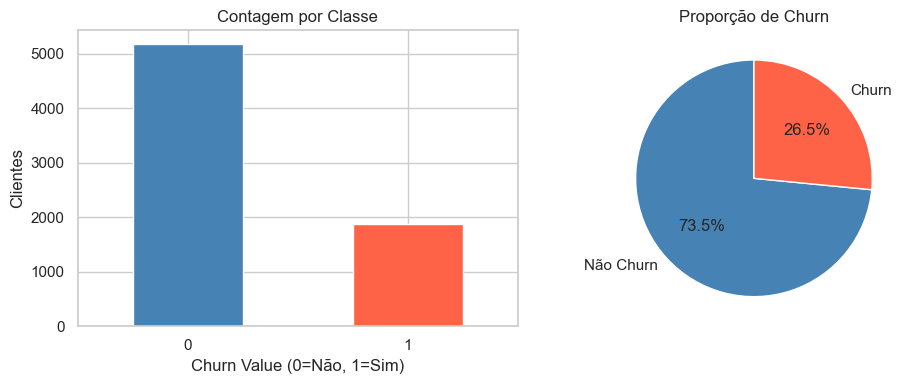

Churn Value
0    73.5
1    26.5

Desbalanceamento: 2.8x mais não-churn que churn


In [5]:
churn_counts = df_raw[TARGET].value_counts()
churn_pct = (churn_counts / len(df_raw) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Contagem por Classe')
axes[0].set_xlabel('Churn Value (0=Não, 1=Sim)')
axes[0].set_ylabel('Clientes')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(churn_counts, labels=['Não Churn', 'Churn'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporção de Churn')
plt.tight_layout()
plt.show()

print(churn_pct.to_string())
print(f'\nDesbalanceamento: {churn_pct[0]/churn_pct[1]:.1f}x mais não-churn que churn')

## 4. Features Numéricas

INFO:customer_churn_ibm.data:Dados limpos: 7043 linhas, 20 colunas


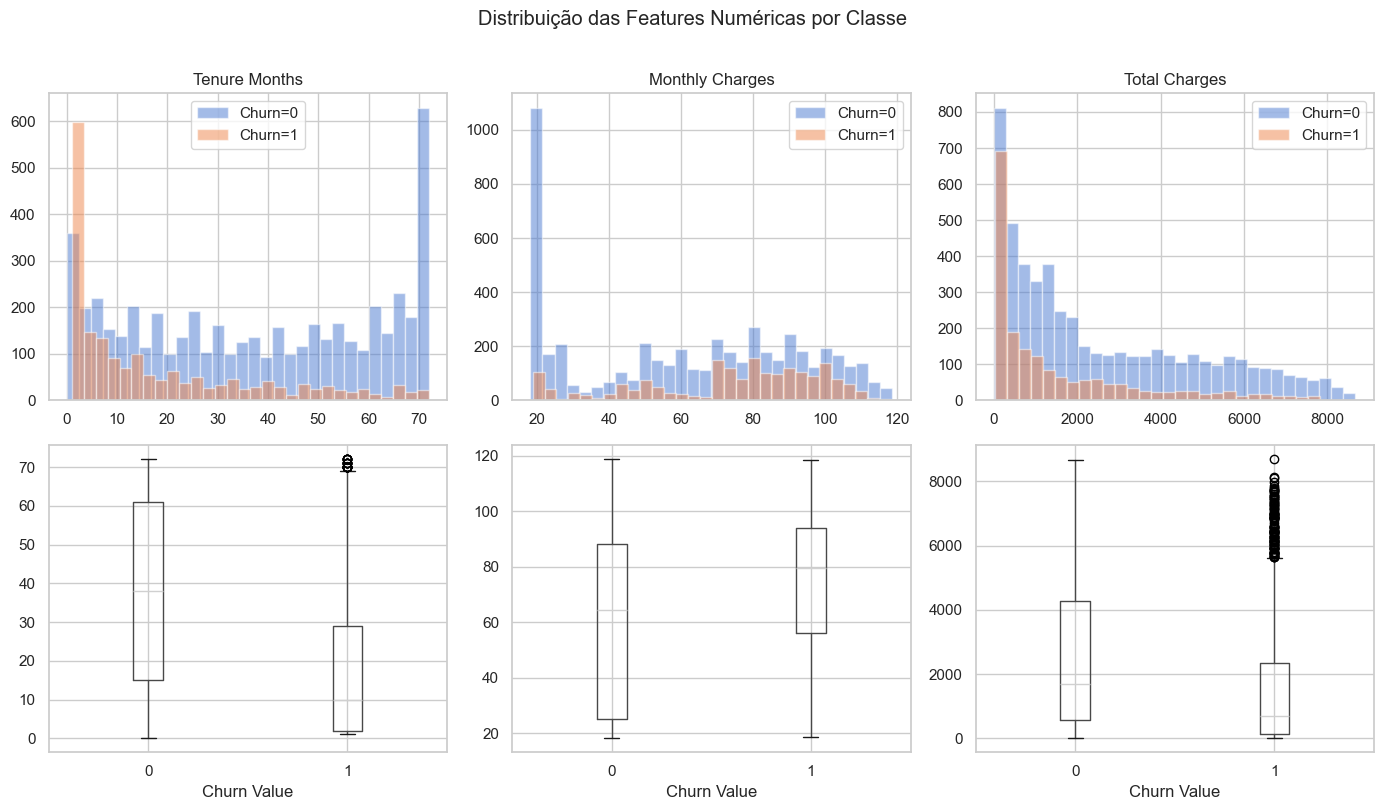

Tenure Months               Monthly Charges                \
                     mean median    std            mean median    std   
Churn Value                                                             
0                   37.57   38.0  24.11           61.27  64.43  31.09   
1                   17.98   10.0  19.53           74.44  79.65  24.67   

            Total Charges                    
                     mean   median      std  
Churn Value                                  
0                 2549.91  1679.52  2329.95  
1                 1531.80   703.55  1890.82

In [6]:
df_clean = clean_data(df_raw)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(NUMERICAL_FEATURES):
    ax_hist = axes[0, i]
    ax_box = axes[1, i]
    for label, grp in df_clean.groupby(TARGET):
        ax_hist.hist(grp[col], alpha=0.5, bins=30, label=f'Churn={label}')
    ax_hist.set_title(col)
    ax_hist.legend()
    df_clean.boxplot(column=col, by=TARGET, ax=ax_box)
    ax_box.set_title('')
    ax_box.set_xlabel('Churn Value')

plt.suptitle('Distribuição das Features Numéricas por Classe', y=1.01)
plt.tight_layout()
plt.show()

df_clean.groupby(TARGET)[NUMERICAL_FEATURES].agg(['mean', 'median', 'std']).round(2)

## 5. Features Categóricas — Taxa de Churn

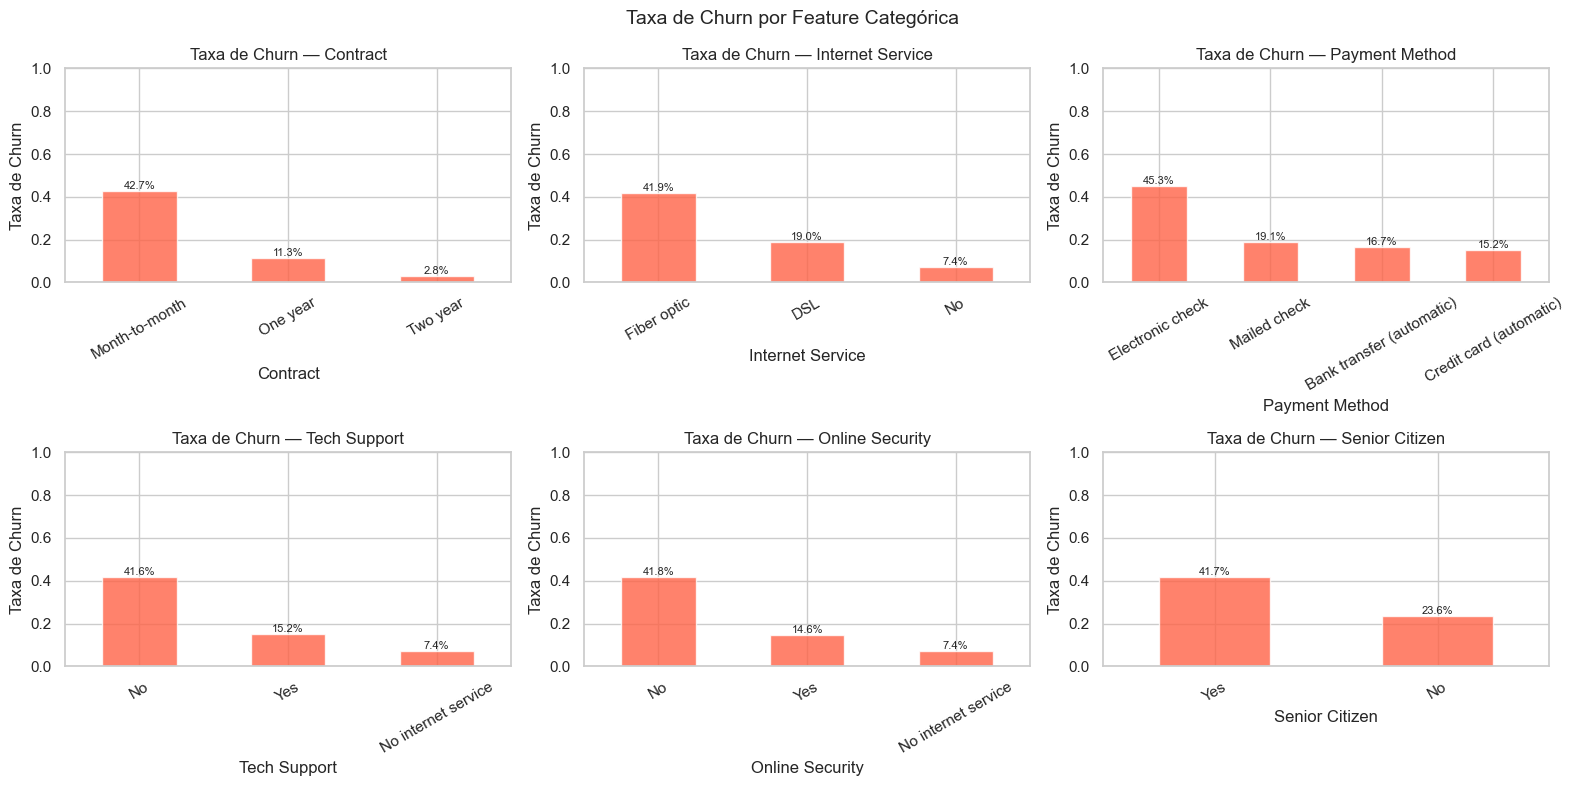

In [7]:
key_cat = ['Contract', 'Internet Service', 'Payment Method', 'Tech Support',
           'Online Security', 'Senior Citizen']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    churn_rate = (
        df_clean.groupby(col)[TARGET].mean().sort_values(ascending=False)
    )
    churn_rate.plot(kind='bar', ax=axes[i], color='tomato', alpha=0.8)
    axes[i].set_title(f'Taxa de Churn — {col}')
    axes[i].set_ylabel('Taxa de Churn')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].annotate(f'{bar.get_height():.1%}',
                         (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha='center', va='bottom', fontsize=8)

plt.suptitle('Taxa de Churn por Feature Categórica', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Correlações — Features Numéricas

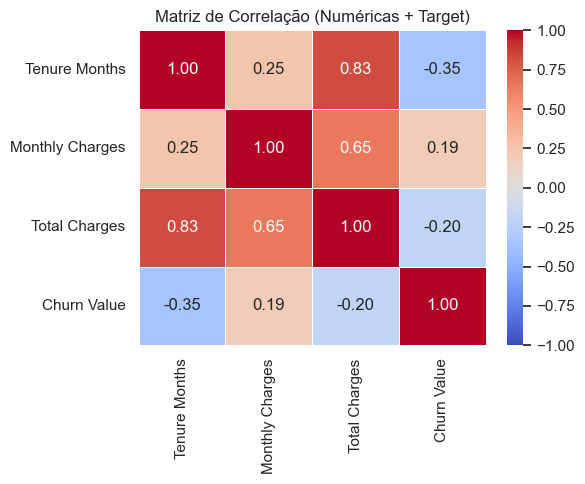

In [8]:
corr_cols = NUMERICAL_FEATURES + [TARGET]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Matriz de Correlação (Numéricas + Target)')
plt.tight_layout()
plt.show()

## 7. Preparação dos Dados

In [9]:
X_train, X_test, y_train, y_test = get_splits(df_clean)
preprocessor = build_preprocessor()

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate treino: {y_train.mean():.2%} | Churn rate teste: {y_test.mean():.2%}')

Train: (5634, 19) | Test: (1409, 19)
Churn rate treino: 26.54% | Churn rate teste: 26.54%


## 8. Baseline com MLflow

In [10]:
mlflow.set_experiment(MLFLOW_EXPERIMENT)
results = train_baselines(preprocessor, X_train, X_test, y_train, y_test)
results

2026/06/29 11:21:56 INFO mlflow.tracking.fluent: Experiment with name 'customer_churn_ibm' does not exist. Creating a new experiment.
INFO:customer_churn_ibm.model_baseline:DummyClassifier         F1=0.0000  AUC-ROC=0.5000  CV-F1=0.0000
INFO:customer_churn_ibm.model_baseline:LogisticRegression      F1=0.6043  AUC-ROC=0.8489  CV-F1=0.6208
INFO:customer_churn_ibm.model_baseline:RandomForest            F1=0.6057  AUC-ROC=0.8449  CV-F1=0.6026
INFO:customer_churn_ibm.model_baseline:GradientBoosting        F1=0.5865  AUC-ROC=0.8523  CV-F1=0.6059


,model,cv_f1,accuracy,precision,recall,f1,roc_auc,pr_auc
0,RandomForest,0.602585,0.804116,0.650307,0.566845,0.605714,0.844920,0.660075
1,LogisticRegression,0.620830,0.801987,0.643505,0.569519,0.604255,0.848867,0.645252
2,GradientBoosting,0.605887,0.799858,0.649351,0.534759,0.586510,0.852251,0.672427
3,DummyClassifier,0.000000,0.734564,0.000000,0.000000,0.000000,0.500000,0.265436


## 9. Validação Cruzada Estratificada

In [11]:
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
cv_rows = []

for name, cfg in BASELINE_CONFIGS.items():
    pipeline = Pipeline([('preprocessor', build_preprocessor()), ('model', cfg['model'])])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({'model': name, 'AUC-ROC mean': scores.mean(), 'AUC-ROC std': scores.std()})
    print(f'{name:22s}  AUC-ROC = {scores.mean():.4f} ± {scores.std():.4f}')

pd.DataFrame(cv_rows).sort_values('AUC-ROC mean', ascending=False).reset_index(drop=True)

DummyClassifier         AUC-ROC = 0.5000 ± 0.0000
LogisticRegression      AUC-ROC = 0.8590 ± 0.0126
RandomForest            AUC-ROC = 0.8529 ± 0.0093
GradientBoosting        AUC-ROC = 0.8631 ± 0.0099


,model,AUC-ROC mean,AUC-ROC std
0,GradientBoosting,0.863083,0.009866
1,LogisticRegression,0.858956,0.012621
2,RandomForest,0.852917,0.009294
3,DummyClassifier,0.500000,0.000000


## 10. Conclusões da Etapa 1

- **Dataset desbalanceado** (~73% não-churn, ~27% churn) — uso de `pos_weight` e métricas além de acurácia.
- **Features mais relevantes (categóricas):** `Contract` (Month-to-month tem taxa de churn ~43%), `Internet Service` (Fiber optic ~41%), `Tech Support` / `Online Security` ausentes.
- **Features numéricas:** `Tenure Months` tem forte correlação negativa com churn — clientes mais antigos tendem a ficar.
- **Leakage evitado:** `Churn Score` e `CLTV` foram removidos por serem derivados do target.
- **Melhor baseline:** GradientBoosting supera Logistic Regression em F1 e AUC-ROC.